In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [8]:
data = pd.read_csv("winequality-white[1].csv",sep=';')
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [ ]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


In [11]:
data.shape

(4898, 12)

In [12]:
data.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [13]:
data.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [14]:
data.duplicated().sum()

np.int64(937)

In [15]:
data = data.drop_duplicates()
data.shape

(3961, 12)

/tmp/ipython-input-2429427742.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=data, palette='mako')


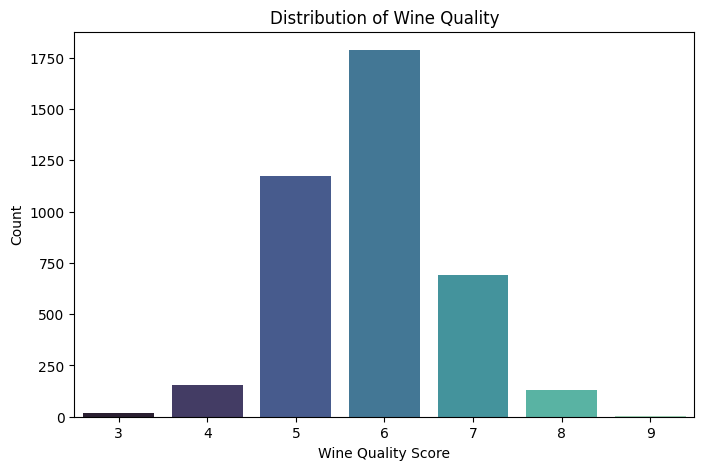

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(x='quality', data=data, palette='mako')
plt.title("Distribution of Wine Quality")
plt.xlabel("Wine Quality Score")
plt.ylabel("Count")
plt.show()

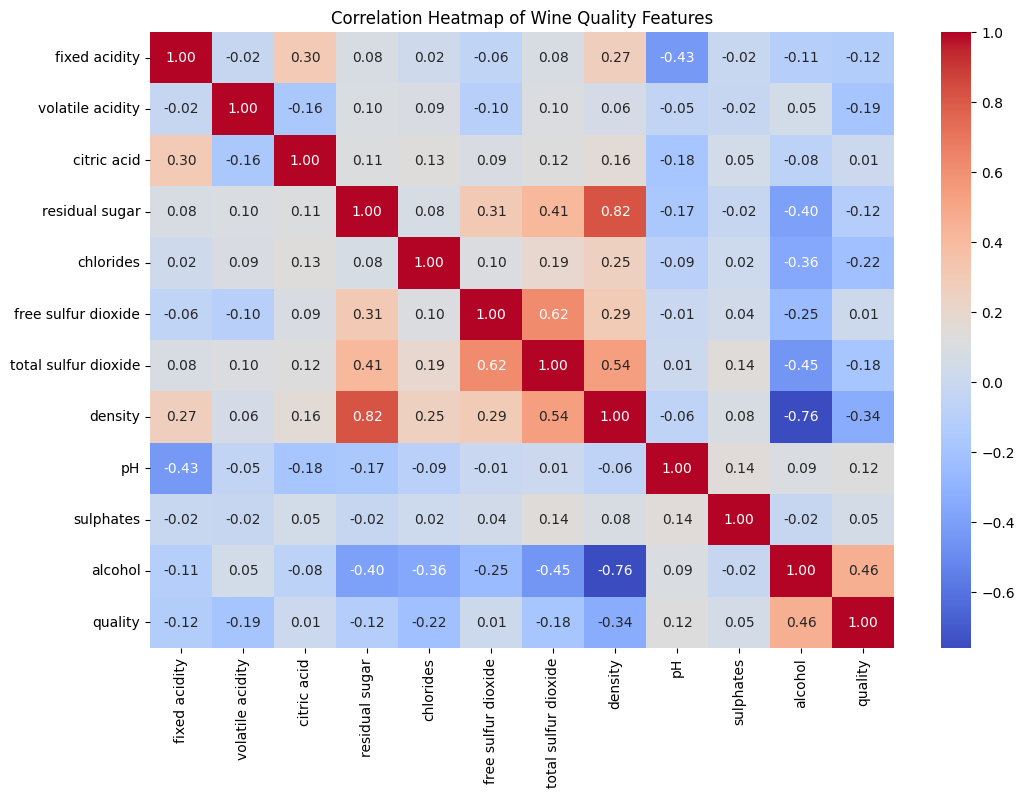

In [17]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap of Wine Quality Features")
plt.show()

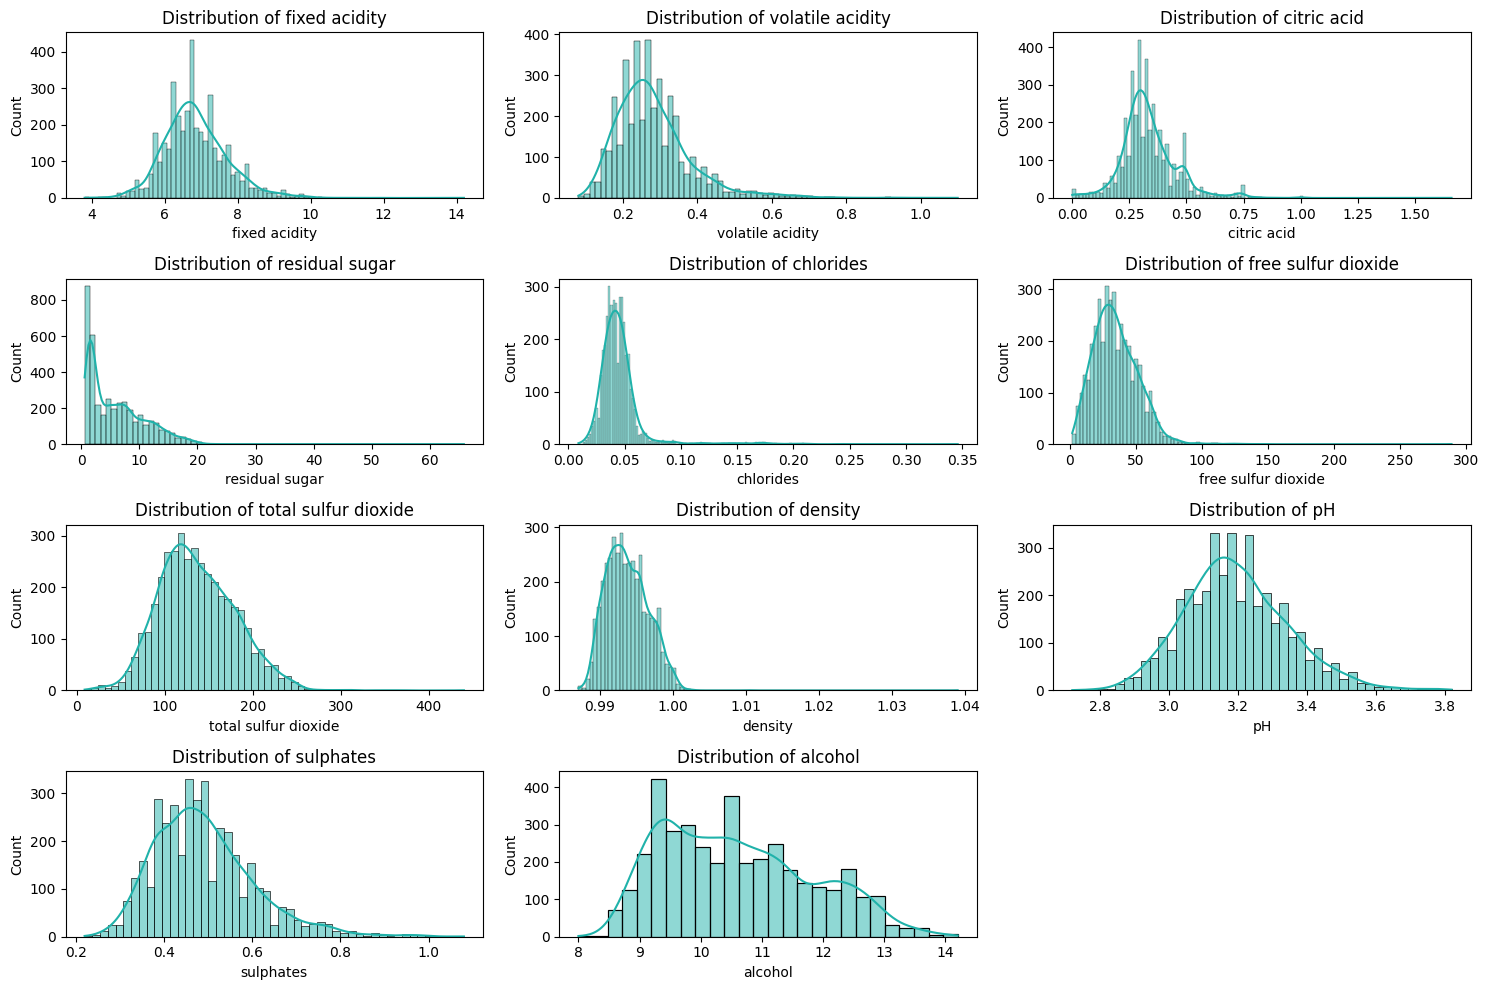

In [18]:
plt.figure(figsize=(15,10))
for i, col in enumerate(data.columns[:-1]):
    plt.subplot(4,3,i+1)
    sns.histplot(data[col], kde=True, color='lightseagreen')
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

In [20]:
X = data.drop('quality', axis=1)
y = data['quality']

In [31]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_scaled)

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((3168, 11), (793, 11))

In [33]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [34]:
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
coeff_df

,Coefficient
fixed acidity,0.026215
volatile acidity,-1.707293
citric acid,0.266986
residual sugar,0.058043
chlorides,-0.630693
free sulfur dioxide,0.006531
total sulfur dioxide,-0.000761
density,-107.706049
pH,0.677472
sulphates,0.597460


In [35]:
model.intercept_

np.float64(107.58227097344928)

In [36]:
y_pred = model.predict(X_test)
y_pred[:15]

array([6.36959317, 5.52124018, 5.37018278, 5.61829253, 6.27993541,
       5.79222766, 6.11888954, 5.32468231, 5.67330762, 6.26060246,
       5.33324751, 5.97842109, 5.89998493, 5.56374205, 5.40331437])

In [37]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("Root Mean Squared Error:", round(rmse,3))
print("R² Score:", round(r2,3))

Root Mean Squared Error: 0.779
R² Score: 0.26


In [38]:
comparison = pd.DataFrame({'Actual Quality': y_test.values, 'Predicted Quality': np.round(y_pred,1)})
comparison.head(20)

,Actual Quality,Predicted Quality
0,4,6.4
1,6,5.5
2,5,5.4
3,6,5.6
4,7,6.3
5,6,5.8
6,6,6.1
7,6,5.3
8,5,5.7
9,5,6.3


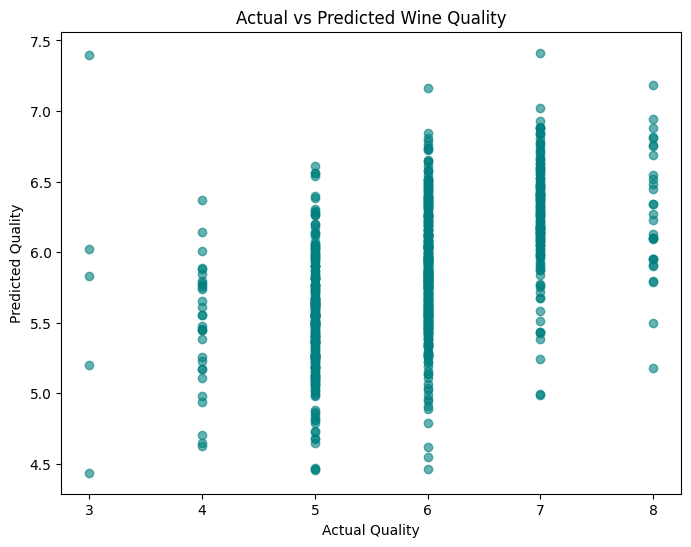

In [39]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='teal', alpha=0.6)
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Actual vs Predicted Wine Quality")
plt.show()

<Figure size 1000x600 with 0 Axes>

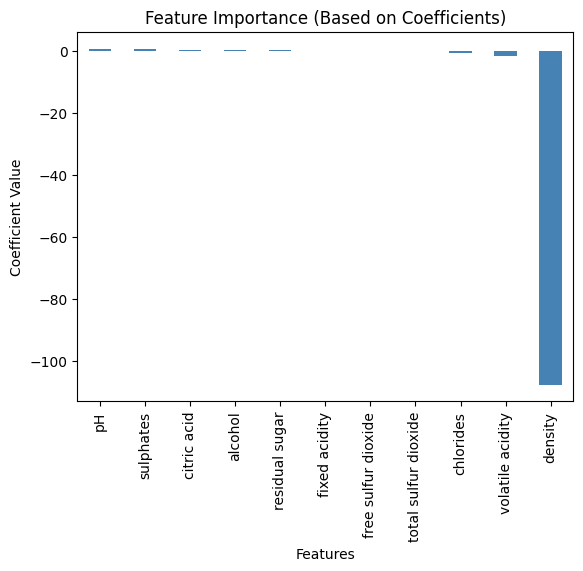

In [40]:
plt.figure(figsize=(10,6))
coeff_df.sort_values(by='Coefficient', ascending=False).plot(kind='bar', legend=False, color='steelblue')
plt.title("Feature Importance (Based on Coefficients)")
plt.ylabel("Coefficient Value")
plt.xlabel("Features")
plt.show()